# Importing dependencies

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

# Configuring graphs

In [2]:
plt.rc('font', **{'family':'serif', 'size': 10})
plt.rc('mathtext', **{'fontset':'cm'})
image_resolution = 600
fontsize_label = 12
fontsize_text = 18
fontsize_legend = 10
markers = ['o', 'v', 's', 'X', 'P', 'p', 'D', 'd', 'H', 'h', 'x', '+']
marker_size = 6
cap_size = 3.0
colors = ['blue', 'red', 'green', 'purple', 'orange', 'brown', 'pink', 'gray', 'olive', 'cyan', 'magenta', 'yellow']

# Thermophysical properties

In [3]:
def rho(temperature, salinity):
    a = [9.999e2, 2.034e-2, -6.162e-3, 2.261e-5, -4.657e-8]
    b = [8.020e2, -2.001, 1.677e-2, -3.060e-5, -1.613e-5]

    temperature_part = a[0] + a[1] * temperature
    temperature_part += a[2] * temperature * temperature
    temperature_part += a[3] * temperature * temperature * temperature
    temperature_part += a[4] * temperature * temperature * temperature * temperature

    salinity_part = b[0] * salinity
    salinity_part += b[1] * salinity * temperature
    salinity_part += b[2] * salinity * temperature * temperature
    salinity_part += b[3] * salinity * temperature * temperature * temperature
    salinity_part += b[4] * salinity * salinity * temperature * temperature

    return temperature_part + salinity_part

# Establishing directories

In [4]:
figures_dir = os.path.join('./figures/')

os.system('mkdir -p ' + figures_dir)

0

# Loading the cases

In [5]:
cases = pd.read_excel('Experimento_bancada.xlsx', 'Cases')
display(cases)

,Case,Feed temperature at the inlet (°C),Coolant temperature at the inlet (°C),Feed salinity at the inlet (g/L),Membrane thickness (m),Membrane porosity,Pore diameter (m),Polymer conductivity (W/mK),Membrane area (m²),Feed channel height (m),...,Coolant flow rate (L/h),Vacuum pressure (Pa),Coolant salinity at the inlet (g/L),Number of channels,Feed temperature at the outlet (°C),Feed temperature at the outlet uncertainty (°C),Coolant temperature at the outlet (°C),Coolant temperature at the outlet uncertainty (°C),Distilled water flux (L/m²h),Distilled water flux uncertainty (L/m²h)
0,Case 1,68.62,25.30,35,0.000125,0.85,2.000000e-07,0.3,0.05,0.002,...,150,0,0,1,65.81,1.37,27.34,0.66,7.627908,0.415794
1,Case 2,78.31,26.47,35,0.000125,0.85,2.000000e-07,0.3,0.05,0.002,...,150,0,0,1,74.20,1.18,29.52,1.24,13.092801,0.515533
2,Case 3,68.66,25.29,85,0.000125,0.85,2.000000e-07,0.3,0.05,0.002,...,150,0,0,1,65.83,0.88,27.28,0.85,7.487761,0.155209
3,Case 4,78.38,26.75,85,0.000125,0.85,2.000000e-07,0.3,0.05,0.002,...,150,0,0,1,74.40,0.84,29.63,3.59,11.451786,0.267357
4,Case 5,68.98,25.07,135,0.000125,0.85,2.000000e-07,0.3,0.05,0.002,...,150,0,0,1,66.03,2.50,27.32,1.08,6.915558,0.123464
5,Case 6,78.04,26.90,135,0.000125,0.85,2.000000e-07,0.3,0.05,0.002,...,150,0,0,1,74.05,0.51,29.85,1.79,10.371094,0.222797
6,Case 7,69.08,25.26,185,0.000125,0.85,2.000000e-07,0.3,0.05,0.002,...,150,0,0,1,66.28,0.68,27.34,1.82,6.064656,0.108651
7,Case 8,78.94,24.68,185,0.000125,0.85,2.000000e-07,0.3,0.05,0.002,...,150,0,0,1,74.95,1.17,27.60,0.59,10.329762,0.180210
8,Case 9,69.17,23.87,235,0.000125,0.85,2.000000e-07,0.3,0.05,0.002,...,150,0,0,1,66.55,0.71,25.88,0.78,5.866357,0.149405
9,Case 10,78.86,25.94,235,0.000125,0.85,2.000000e-07,0.3,0.05,0.002,...,150,0,0,1,75.03,0.71,28.64,0.78,9.467148,0.178543


# Running the cases

In [6]:
def salinity_equation(x, salinity, temperature):
    return rho(temperature, x) * x - salinity

In [7]:
results = pd.DataFrame(columns=[
    'Case', 'Permeate flux (L/m²h)', 'Exp. permeate flux (L/m²h)', 'Hot feedwater outlet temperature (°C)',
    'Exp. hot feedwater outlet temperature (°C)', 'Cold feedwater outlet temperature (°C)', 'Exp. cold feedwater outlet temperature (°C)',
    'Heat flux (W/m²)', 'Vapor heat flux (W/m²)', 'GOR', 'STECth', 'Thermal efficiency (%)'
])

for index, elem in cases.iterrows():
    hot_feedwater_inlet_temperature = elem['Feed temperature at the inlet (°C)']
    cold_feedwater_inlet_temperature = elem['Coolant temperature at the inlet (°C)']
    vacuum_pressure = elem['Vacuum pressure (Pa)']
    initial_guess = elem['Feed salinity at the inlet (g/L)'] / 1000.0
    feed_salinity = fsolve(salinity_equation, initial_guess, args=(elem['Feed salinity at the inlet (g/L)'], elem['Feed temperature at the inlet (°C)']))[0]
    initial_guess = elem['Coolant salinity at the inlet (g/L)'] / 1000.0
    cool_salinity = fsolve(salinity_equation, initial_guess, args=(elem['Coolant salinity at the inlet (g/L)'], elem['Coolant temperature at the inlet (°C)']))[0]
    feed_mass_flow_rate = rho(hot_feedwater_inlet_temperature, feed_salinity) * elem['Feed flow rate (L/h)'] / 3600000.0
    cool_mass_flow_rate = rho(cold_feedwater_inlet_temperature, cool_salinity) * elem['Coolant flow rate (L/h)'] / 3600000.0
    membrane_area = elem['Membrane area (m²)']
    membrane_thickness = elem['Membrane thickness (m)']
    membrane_porosity = elem['Membrane porosity']
    pore_diameter = elem['Pore diameter (m)']
    polymer_conductivity = elem['Polymer conductivity (W/mK)']
    feed_channel_height = elem['Feed channel height (m)']
    cold_channel_height = elem['Cold channel height (m)']
    channel_width = elem['Channel width (m)']
    spacer_porosity = elem['Spacer porosity']
    gap_spacer_porosity = elem['Gap spacer porosity']
    air_gap_thickness = elem['Air gap thickness (m)']
    wall_thickness = elem['Wall thickness (m)']
    spacer_conductivity = elem['Spacer thermal conductivity (W/mK)']
    wall_conductivity = elem['Condensing wall thermal conductivity (W/mK)']
    number_channels = elem['Number of channels']
    print('Salinity = ', str(elem['Feed salinity at the inlet (g/L)']), ' g/L')
    os.system('./bin/vagmd0Dmodel -entry_temperature_feed ' + str(hot_feedwater_inlet_temperature) +
              ' -entry_temperature_cool ' + str(cold_feedwater_inlet_temperature) +
              ' -feed_mass_flow_rate ' + str(feed_mass_flow_rate) +
              ' -cool_mass_flow_rate ' + str(feed_mass_flow_rate) +
              ' -vacuum_pressure ' + str(vacuum_pressure) +
              ' -entry_salinity_feed ' + str(feed_salinity) +
              ' -entry_salinity_cool ' + str(cool_salinity) +
              ' -membrane_area ' + str(membrane_area) +
              ' -number_channels ' + str(number_channels) +
              ' -wall_conductivity ' + str(wall_conductivity) +
              ' -spacer_conductivity ' + str(spacer_conductivity) +
              ' -wall_thickness ' + str(wall_thickness) +
              ' -air_gap_thickness ' + str(air_gap_thickness) +
              ' -gap_spacer_porosity ' + str(gap_spacer_porosity) +
              ' -spacer_porosity ' + str(spacer_porosity) +
              ' -channel_width ' + str(channel_width) +
              ' -feed_channel_height ' + str(feed_channel_height) +
              ' -cold_channel_height ' + str(cold_channel_height) +
              ' -polymer_conductivity ' + str(polymer_conductivity) +
              ' -pore_diameter ' + str(pore_diameter) +
              ' -membrane_porosity ' + str(membrane_porosity) +
              ' -membrane_thickness ' + str(membrane_thickness))

    report = pd.read_csv('./results/report.csv', header=None)
    mass_flux = report[report[0] == 'Mass flux ='][1].values[0]
    film_temperature = report[report[0] == 'Temperature at the interface between the gap and the distillate film ='][1].values[0]
    hot_feedwater_outlet_temperature = report[report[0] == 'Feed temperature at the outlet of the module ='][1].values[0]
    cold_feedwater_outlet_temperature = report[report[0] == 'Coolant temperature at the outlet of the module ='][1].values[0]
    heat_flux = report[report[0] == 'Heat flux ='][1].values[0]
    vapor_heat_flux = report[report[0] == 'Vapor heat flux ='][1].values[0]
    GOR = report[report[0] == 'Gain-output ratio (GOR) ='][1].values[0]
    STECth = report[report[0] == 'Specific thermal energy consumption (SECth) ='][1].values[0]
    thermal_efficiency = report[report[0] == 'Thermal efficiency ='][1].values[0]
    new_row = pd.DataFrame([{
        'Case': elem['Case'],
        'Permeate flux (L/m²h)': 1000.0 * mass_flux / rho(film_temperature, 0.0),
        'Exp. permeate flux (L/m²h)': elem['Distilled water flux (L/m²h)'],
        'Hot feedwater outlet temperature (°C)': hot_feedwater_outlet_temperature,
        'Exp. hot feedwater outlet temperature (°C)': elem['Feed temperature at the outlet (°C)'],
        'Cold feedwater outlet temperature (°C)': cold_feedwater_outlet_temperature,
        'Exp. cold feedwater outlet temperature (°C)': elem['Coolant temperature at the outlet (°C)'],
        'Heat flux (W/m²)': heat_flux,
        'Vapor heat flux (W/m²)': vapor_heat_flux,
        'GOR': GOR,
        'STECth': STECth,
        'Thermal efficiency (%)': thermal_efficiency
    }])
    results = pd.concat([results, new_row], ignore_index=True)

Salinity =  35  g/L
Salinity =  35  g/L
Salinity =  85  g/L
Salinity =  85  g/L
Salinity =  135  g/L
Salinity =  135  g/L
Salinity =  185  g/L
Salinity =  185  g/L
Salinity =  235  g/L
Salinity =  235  g/L
Salinity =  260  g/L
Salinity =  260  g/L
Salinity =  285  g/L
Salinity =  285  g/L
Salinity =  300  g/L
Salinity =  300  g/L


In [8]:
display(results)

,Case,Permeate flux (L/m²h),Exp. permeate flux (L/m²h),Hot feedwater outlet temperature (°C),Exp. hot feedwater outlet temperature (°C),Cold feedwater outlet temperature (°C),Exp. cold feedwater outlet temperature (°C),Heat flux (W/m²),Vapor heat flux (W/m²),GOR,STECth,Thermal efficiency (%)
0,Case 1,7.301981,7.627908,66.890516,65.81,26.960405,27.34,5815.895792,4551.175179,0.039905,20045.691426,78.254070
1,Case 2,11.727433,13.092801,75.721820,74.20,28.958077,29.52,8664.732367,7218.454976,0.050461,14719.989013,83.308459
2,Case 3,7.074482,7.487761,67.005449,65.83,26.795930,27.28,5455.864099,4174.737911,0.036017,21503.355185,76.518363
3,Case 4,11.370159,11.451786,75.922731,74.40,28.988697,29.63,8066.221472,6602.460472,0.045367,15719.984152,81.853201
4,Case 5,6.904159,6.915558,67.384090,66.03,26.454303,27.32,5171.192135,3859.773629,0.032594,23074.381993,74.639919
5,Case 6,10.714706,10.371094,75.758817,74.05,28.879711,29.85,7359.233378,5883.480893,0.040307,17127.687355,79.946926
6,Case 7,6.583420,6.064656,67.572042,66.28,26.512579,27.34,4813.066031,3490.204698,0.029463,24915.375637,72.515205
7,Case 8,10.688119,10.329762,76.692741,74.95,26.546063,27.60,7136.047101,5543.258617,0.035659,18806.372631,77.679681
8,Case 9,6.271507,5.866357,67.729312,66.55,25.020879,25.88,4540.348386,3155.571811,0.026106,27833.316494,69.500654
9,Case 10,9.946650,9.467148,76.799275,75.03,27.585111,28.64,6458.931524,4884.679166,0.032118,20311.705360,75.626737


In [9]:
100.0 * (results['Permeate flux (L/m²h)'] - results['Exp. permeate flux (L/m²h)']) / results['Exp. permeate flux (L/m²h)']

0     -4.272827
1    -10.428381
2     -5.519400
3     -0.712788
4     -0.164831
5      3.313171
6      8.553891
7      3.469165
8      6.906341
9      5.064907
10    14.812551
11    18.475272
12    25.542506
13    16.944798
14    96.805271
15    18.834144
dtype: float64

# Plot the results for different salinities

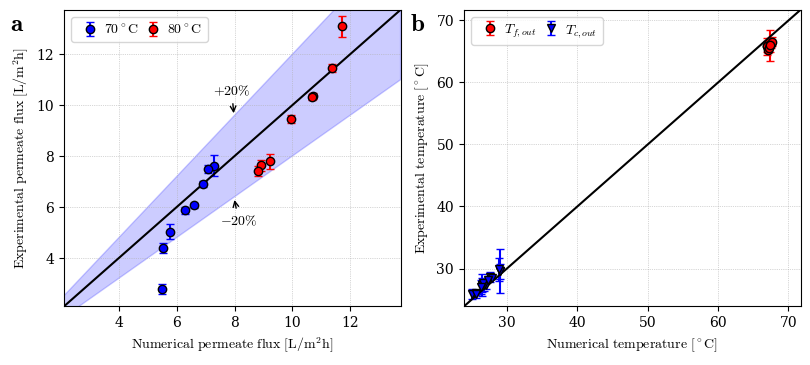

In [22]:
min_mass_flux = np.amin([0.75 * np.amin(results['Permeate flux (L/m²h)']), 0.75 * np.amin(results['Exp. permeate flux (L/m²h)'])])
max_mass_flux = np.amax([1.05 * np.amax(results['Permeate flux (L/m²h)']), 1.05 * np.amax(results['Exp. permeate flux (L/m²h)'])])

max_temperature = np.amin([1.1 * np.amin(results['Hot feedwater outlet temperature (°C)']), 1.1 * np.amin(results['Exp. hot feedwater outlet temperature (°C)'])])
min_temperature = np.amax([0.8 * np.amax(results['Cold feedwater outlet temperature (°C)']), 0.8 * np.amax(results['Exp. cold feedwater outlet temperature (°C)'])])

mass_flux_line = np.linspace(min_mass_flux, max_mass_flux, 100)
temperature_line = np.linspace(min_temperature, max_temperature, 100)

figval, axsval = plt.subplots(nrows=1, ncols=2, figsize=(8.0, 3.5), layout='constrained')

axsval[0].errorbar(results['Permeate flux (L/m²h)'][::2],
                   results['Exp. permeate flux (L/m²h)'][::2],
                   yerr=cases['Distilled water flux uncertainty (L/m²h)'][::2],
                   marker=markers[0], markersize=marker_size, markeredgecolor='black', color=colors[0], capsize=cap_size, label=r'$70^\circ \mathrm{C}$', linestyle='None')
axsval[0].errorbar(results['Permeate flux (L/m²h)'][1::2],
                   results['Exp. permeate flux (L/m²h)'][1::2],
                   yerr=cases['Distilled water flux uncertainty (L/m²h)'][::2],
                   marker=markers[0], markersize=marker_size, markeredgecolor='black', color=colors[1], capsize=cap_size, label=r'$80^\circ \mathrm{C}$', linestyle='None')
axsval[0].plot(mass_flux_line, mass_flux_line, color='black')

axsval[0].fill_between(mass_flux_line, 0.8 * mass_flux_line, 1.2 * mass_flux_line, color='blue', alpha=0.2)

axsval[0].annotate(r'$\mathrm{+20\%}$', xy=(mass_flux_line[50], 1.2 * mass_flux_line[50]), xytext=(-15, 15), textcoords='offset points', arrowprops=dict(arrowstyle='->'))
axsval[0].annotate(r'$\mathrm{-20\%}$', xy=(mass_flux_line[50], 0.8 * mass_flux_line[50]), xytext=(-10, -20), textcoords='offset points', arrowprops=dict(arrowstyle='->'))

axsval[0].legend(fontsize=fontsize_legend, ncols=2, handletextpad=0.01, columnspacing=0.01)

axsval[0].set_xlim(min_mass_flux, max_mass_flux)
axsval[0].set_ylim(min_mass_flux, max_mass_flux)

# axsval[0].legend(fontsize=fontsize_legend, ncols=2, handletextpad=0.01, columnspacing=0.01)
axsval[0].grid(linestyle='dotted', linewidth=0.5)

# axsval[0].set_xticks(np.arange(0.2, 3.6, 0.5))
# axsval[0].set_yticks(np.arange(0.2, 3.6, 0.5))
axsval[0].set_xlabel(r'$\mathrm{Numerical\ permeate\ flux\ [L/m^2h]}$')
axsval[0].set_ylabel(r'$\mathrm{Experimental\ permeate\ flux\ [L/m^2h]}$')

axsval[1].errorbar(results['Hot feedwater outlet temperature (°C)'],
                   results['Exp. hot feedwater outlet temperature (°C)'],
                   yerr=cases['Feed temperature at the outlet uncertainty (°C)'],
                   marker=markers[0], markersize=marker_size, markeredgecolor='black', color=colors[1], capsize=cap_size, label=r'$T_{f,out}$', linestyle='None')
axsval[1].errorbar(results['Cold feedwater outlet temperature (°C)'],
                   results['Exp. cold feedwater outlet temperature (°C)'],
                   yerr=cases['Coolant temperature at the outlet uncertainty (°C)'],
                   marker=markers[1], markersize=marker_size, markeredgecolor='black', color=colors[0], capsize=cap_size, label=r'$T_{c,out}$', linestyle='None')
axsval[1].plot(temperature_line, temperature_line, color='black')

axsval[1].set_xlim(min_temperature, max_temperature)
axsval[1].set_ylim(min_temperature, max_temperature)

axsval[1].legend(fontsize=fontsize_legend, ncols=3, handletextpad=0.01, columnspacing=0.01)
axsval[1].grid(linestyle='dotted', linewidth=0.5)

# axsval[1].set_xticks(np.arange(27.0, 87.0, 10.0))
# axsval[1].set_yticks(np.arange(27.0, 87.0, 10.0))
axsval[1].set_xlabel(r'$\mathrm{Numerical\ temperature\ [^\circ C]}$')
axsval[1].set_ylabel(r'$\mathrm{Experimental\ temperature\ [^\circ C]}$')

axsval[0].text(-0.16, 0.93, r'$\mathbf{a}$', transform=axsval[0].transAxes, fontsize=fontsize_text, fontweight='bold')
axsval[1].text(-0.16, 0.93, r'$\mathbf{b}$', transform=axsval[1].transAxes, fontsize=fontsize_text, fontweight='bold')

figval.savefig(figures_dir + 'validation_salinity.png', dpi=image_resolution, bbox_inches='tight', pad_inches=0.01)